

# Tugas 6 - Naive Bayes

## Klasifikasi Minat Membeli Produk Secara Online

Data uji:
- Harga = Sedang
- Diskon = Ada
- Ulasan = Baik

---

**Nama:** Panji Kurnia Akbar  
**NIM:** 2024081024  
**Tgl:** 2 April 2026  
**Mata Kuliah:** Introduction to AI

---

## 1) Setup Notebook

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)

TARGET_COL = "Hasil"
FEATURE_COLS = ["Harga", "Diskon", "Ulasan"]
CLASS_ORDER = ["Tertarik", "Tidak Tertarik"]


def load_data() -> pd.DataFrame:
    """Membuat DataFrame data latih sesuai soal tugas."""
    rows = [
        [1, "Murah", "Ada", "Baik", "Tertarik"],
        [2, "Murah", "Ada", "Baik", "Tertarik"],
        [3, "Sedang", "Ada", "Baik", "Tertarik"],
        [4, "Mahal", "Tidak Ada", "Buruk", "Tidak Tertarik"],
        [5, "Mahal", "Tidak Ada", "Buruk", "Tidak Tertarik"],
        [6, "Sedang", "Ada", "Baik", "Tertarik"],
        [7, "Sedang", "Tidak Ada", "Baik", "Tertarik"],
        [8, "Mahal", "Ada", "Buruk", "Tidak Tertarik"],
    ]
    return pd.DataFrame(rows, columns=["No", "Harga", "Diskon", "Ulasan", "Hasil"])


def normalize_data(df: pd.DataFrame) -> pd.DataFrame:
    """Merapikan nilai agar konsisten dan mudah dihitung."""
    clean_df = df.copy()
    clean_df.columns = [col.strip().title() for col in clean_df.columns]

    for col in ["Harga", "Diskon", "Ulasan", "Hasil"]:
        clean_df[col] = clean_df[col].astype(str).str.strip()

    valid_values = {
        "Harga": {"Murah", "Sedang", "Mahal"},
        "Diskon": {"Ada", "Tidak Ada"},
        "Ulasan": {"Baik", "Buruk"},
        "Hasil": {"Tertarik", "Tidak Tertarik"},
    }

    for col, allowed in valid_values.items():
        invalid = set(clean_df[col].dropna().unique()) - allowed
        if invalid:
            raise ValueError(f"Nilai tidak valid pada kolom {col}: {invalid}")

    if clean_df[["Harga", "Diskon", "Ulasan", "Hasil"]].isnull().any().any():
        raise ValueError("Ditemukan nilai kosong pada data latih.")

    return clean_df


def compute_frequency(df: pd.DataFrame, feature: str) -> pd.DataFrame:
    """Menghitung frekuensi nilai fitur terhadap kelas target."""
    freq = pd.crosstab(df[feature], df[TARGET_COL]).reindex(columns=CLASS_ORDER, fill_value=0)
    return freq


def compute_prior(df: pd.DataFrame) -> pd.DataFrame:
    """Menghitung prior probability setiap kelas."""
    counts = df[TARGET_COL].value_counts().reindex(CLASS_ORDER, fill_value=0)
    prior = counts / len(df)
    return pd.DataFrame({"Jumlah": counts, "Prior": prior})


def compute_likelihood(df: pd.DataFrame, laplace: bool = False) -> pd.DataFrame:
    """Menghitung likelihood P(x_i | y) untuk semua nilai fitur dan kelas."""
    records = []
    class_counts = df[TARGET_COL].value_counts().to_dict()

    for feature in FEATURE_COLS:
        values = sorted(df[feature].unique())
        k = len(values)

        for value in values:
            for cls in CLASS_ORDER:
                match_count = ((df[feature] == value) & (df[TARGET_COL] == cls)).sum()
                denominator = class_counts.get(cls, 0)

                if laplace:
                    prob = (match_count + 1) / (denominator + k)
                else:
                    prob = match_count / denominator if denominator > 0 else 0.0

                records.append(
                    {
                        "Feature": feature,
                        "Value": value,
                        "Class": cls,
                        "Count": match_count,
                        "Likelihood": prob,
                    }
                )

    return pd.DataFrame(records)


def compute_posterior(prior_df: pd.DataFrame, likelihood_df: pd.DataFrame, x_test: dict) -> pd.DataFrame:
    """Menghitung posterior proporsional P(y) * product(P(x_i | y))."""
    rows = []

    for cls in CLASS_ORDER:
        prior_prob = prior_df.loc[cls, "Prior"]
        score = prior_prob

        for feature in FEATURE_COLS:
            value = x_test[feature]
            like = likelihood_df[
                (likelihood_df["Feature"] == feature)
                & (likelihood_df["Value"] == value)
                & (likelihood_df["Class"] == cls)
            ]["Likelihood"].iloc[0]
            score *= like

        rows.append({"Class": cls, "Posterior_Proportional": score})

    post = pd.DataFrame(rows).set_index("Class")
    total_score = post["Posterior_Proportional"].sum()
    post["Posterior_Normalized"] = post["Posterior_Proportional"] / total_score if total_score > 0 else 0.0
    return post


def predict_class(posterior_df: pd.DataFrame) -> str:
    """Memilih kelas dengan nilai posterior proporsional paling besar."""
    return posterior_df["Posterior_Proportional"].idxmax()


def render_summary(prior_df: pd.DataFrame, posterior_df: pd.DataFrame, prediction: str) -> pd.DataFrame:
    """Menyusun tabel ringkasan akhir yang mudah dibaca."""
    summary = pd.DataFrame(
        {
            "Prior": prior_df["Prior"],
            "Posterior (Proporsional)": posterior_df["Posterior_Proportional"],
            "Posterior (Normalized)": posterior_df["Posterior_Normalized"],
        }
    )
    display(Markdown(f"### Prediksi Akhir: **{prediction.upper()}**"))
    return summary

## 2) Muat Data Latih ke Pandas DataFrame (Table)

In [20]:
df_raw = load_data()
display(df_raw)

,No,Harga,Diskon,Ulasan,Hasil
0,1,Murah,Ada,Baik,Tertarik
1,2,Murah,Ada,Baik,Tertarik
2,3,Sedang,Ada,Baik,Tertarik
3,4,Mahal,Tidak Ada,Buruk,Tidak Tertarik
4,5,Mahal,Tidak Ada,Buruk,Tidak Tertarik
5,6,Sedang,Ada,Baik,Tertarik
6,7,Sedang,Tidak Ada,Baik,Tertarik
7,8,Mahal,Ada,Buruk,Tidak Tertarik


## 3) Normalisasi Nilai Atribut

In [21]:
df = normalize_data(df_raw)
display(df)

,No,Harga,Diskon,Ulasan,Hasil
0,1,Murah,Ada,Baik,Tertarik
1,2,Murah,Ada,Baik,Tertarik
2,3,Sedang,Ada,Baik,Tertarik
3,4,Mahal,Tidak Ada,Buruk,Tidak Tertarik
4,5,Mahal,Tidak Ada,Buruk,Tidak Tertarik
5,6,Sedang,Ada,Baik,Tertarik
6,7,Sedang,Tidak Ada,Baik,Tertarik
7,8,Mahal,Ada,Buruk,Tidak Tertarik


## 4) Hitung Frekuensi Atribut per Kelas (Bar Chart)

#### Tabel Frekuensi - Harga

Hasil,Tertarik,Tidak Tertarik
Harga,,
Mahal,0,3
Murah,2,0
Sedang,3,0


#### Tabel Frekuensi - Diskon

Hasil,Tertarik,Tidak Tertarik
Diskon,,
Ada,4,1
Tidak Ada,1,2


#### Tabel Frekuensi - Ulasan

Hasil,Tertarik,Tidak Tertarik
Ulasan,,
Baik,5,0
Buruk,0,3


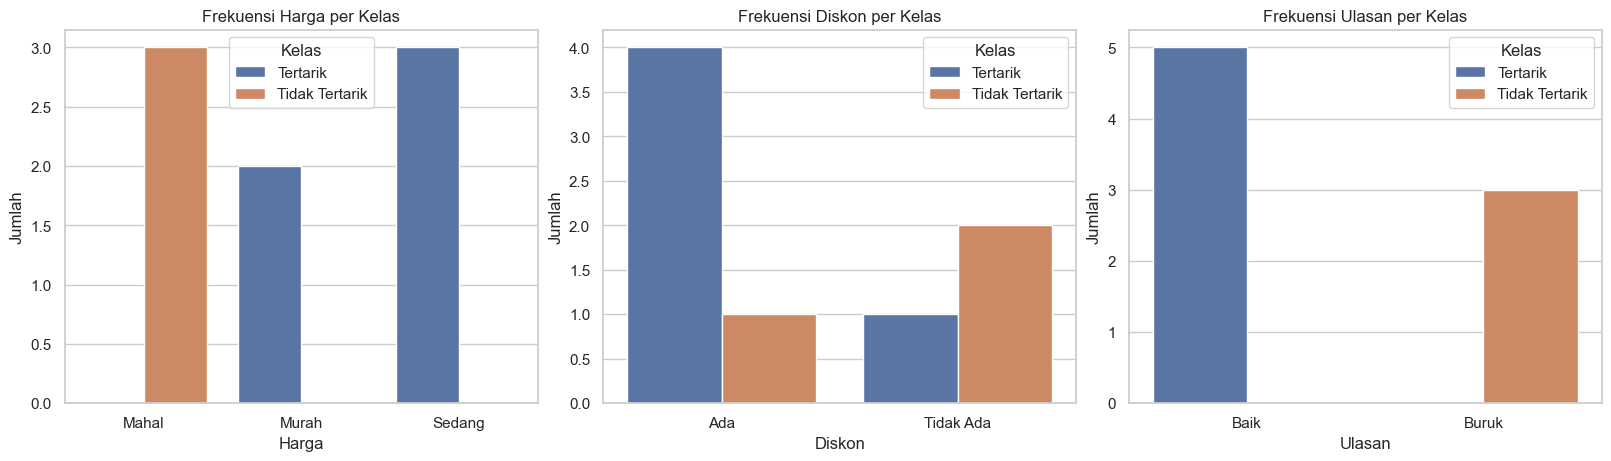

In [22]:
frequency_tables = {}
for feature in FEATURE_COLS:
    freq = compute_frequency(df, feature)
    frequency_tables[feature] = freq
    display(Markdown(f"#### Tabel Frekuensi - {feature}"))
    display(freq)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
for i, feature in enumerate(FEATURE_COLS):
    freq_plot = frequency_tables[feature].reset_index().melt(
        id_vars=feature,
        value_vars=CLASS_ORDER,
        var_name="Kelas",
        value_name="Jumlah"
    )
    sns.barplot(data=freq_plot, x=feature, y="Jumlah", hue="Kelas", ax=axes[i])
    axes[i].set_title(f"Frekuensi {feature} per Kelas")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Jumlah")

plt.show()

## 5) Hitung Prior Probability Kelas (Pie Chart + Table)

,Jumlah,Prior
Hasil,,
Tertarik,5,0.625
Tidak Tertarik,3,0.375


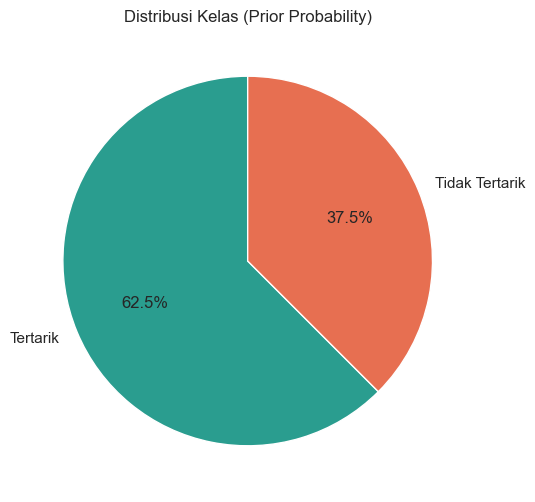

In [23]:
prior_df = compute_prior(df)
display(prior_df)

plt.figure(figsize=(6, 6))
plt.pie(
    prior_df["Jumlah"],
    labels=prior_df.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2a9d8f", "#e76f51"]
)
plt.title("Distribusi Kelas (Prior Probability)")
plt.show()

## 6) Hitung Likelihood P(x_i | y) (Heatmap)

,Feature,Value,Class,Count,Likelihood
0,Harga,Mahal,Tertarik,0,0.000000
1,Harga,Mahal,Tidak Tertarik,3,1.000000
2,Harga,Murah,Tertarik,2,0.400000
3,Harga,Murah,Tidak Tertarik,0,0.000000
4,Harga,Sedang,Tertarik,3,0.600000
5,Harga,Sedang,Tidak Tertarik,0,0.000000
6,Diskon,Ada,Tertarik,4,0.800000
7,Diskon,Ada,Tidak Tertarik,1,0.333333
8,Diskon,Tidak Ada,Tertarik,1,0.200000
9,Diskon,Tidak Ada,Tidak Tertarik,2,0.666667


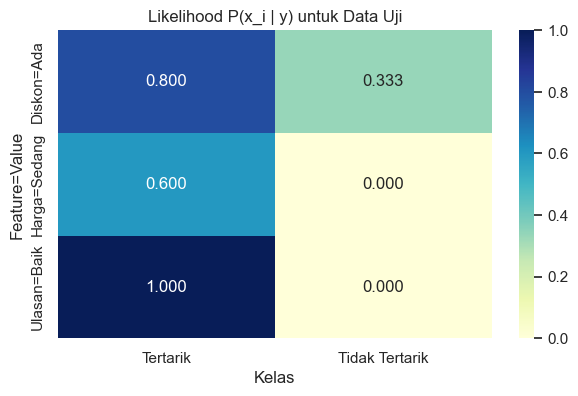

In [24]:
likelihood_df = compute_likelihood(df, laplace=False)
display(likelihood_df)

# Heatmap likelihood khusus data uji: Sedang, Ada, Baik
x_test = {"Harga": "Sedang", "Diskon": "Ada", "Ulasan": "Baik"}
selected_like = likelihood_df[likelihood_df["Value"].isin(x_test.values())].copy()
selected_like["FeatureValue"] = selected_like["Feature"] + "=" + selected_like["Value"]
heatmap_df = selected_like.pivot(index="FeatureValue", columns="Class", values="Likelihood")

plt.figure(figsize=(7, 4))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Likelihood P(x_i | y) untuk Data Uji")
plt.xlabel("Kelas")
plt.ylabel("Feature=Value")
plt.show()

## 7) Hitung Posterior untuk Data Uji (Bar Chart)

,Posterior_Proportional,Posterior_Normalized
Class,,
Tertarik,0.3,1.0
Tidak Tertarik,0.0,0.0


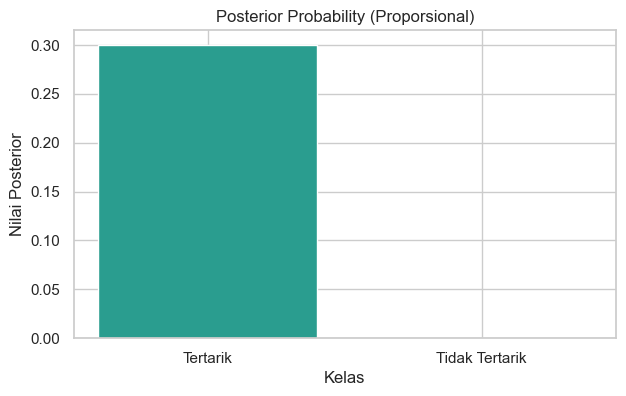

In [25]:
posterior_df = compute_posterior(prior_df, likelihood_df, x_test)
display(posterior_df)

plt.figure(figsize=(7, 4))
colors = ["#2a9d8f", "#e76f51"]
plt.bar(posterior_df.index, posterior_df["Posterior_Proportional"], color=colors)
plt.title("Posterior Probability (Proporsional)")
plt.ylabel("Nilai Posterior")
plt.xlabel("Kelas")
plt.show()

## 8) Tentukan Prediksi Akhir dan Tampilkan Ringkasan (Summary Text + Highlight)

In [26]:
prediction = predict_class(posterior_df)
summary_df = render_summary(prior_df, posterior_df, prediction)

# Highlight kelas prediksi tanpa ketergantungan Styler/Jinja2
summary_display = summary_df.copy().round(3)
summary_display["Highlight"] = ["<< PREDIKSI" if idx == prediction else "" for idx in summary_display.index]
display(summary_display)

# Jelaskan alasan klasifikasi
display(Markdown("**Alasan**: Kelas dengan posterior proporsional tertinggi dipilih sebagai hasil klasifikasi."
                 " Pada data ini, kombinasi Harga=Sedang, Diskon=Ada, dan Ulasan=Baik"
                 " menghasilkan posterior lebih besar untuk kelas Tertarik."))

### Prediksi Akhir: **TERTARIK**

,Prior,Posterior (Proporsional),Posterior (Normalized),Highlight
Tertarik,0.625,0.3,1.0,<< PREDIKSI
Tidak Tertarik,0.375,0.0,0.0,


**Alasan**: Kelas dengan posterior proporsional tertinggi dipilih sebagai hasil klasifikasi. Pada data ini, kombinasi Harga=Sedang, Diskon=Ada, dan Ulasan=Baik menghasilkan posterior lebih besar untuk kelas Tertarik.

## 9) Validasi Hasil dan Ekspor Notebook

In [27]:
# Validasi sederhana
assert np.isclose(prior_df["Prior"].sum(), 1.0), "Total prior probability harus = 1"
assert (likelihood_df["Likelihood"] >= 0).all() and (likelihood_df["Likelihood"] <= 1).all(), "Likelihood harus berada di [0, 1]"
assert (posterior_df["Posterior_Proportional"] >= 0).all(), "Posterior proporsional tidak boleh negatif"

print("Validasi berhasil: semua nilai probabilitas valid.")

Validasi berhasil: semua nilai probabilitas valid.


## Penjelasan Hasil

Berdasarkan perhitungan Naive Bayes pada data uji (Harga=Sedang, Diskon=Ada, Ulasan=Baik), kelas **Tertarik** memiliki nilai posterior lebih tinggi dibanding kelas **Tidak Tertarik**.

Hal ini terjadi karena kombinasi fitur pada data uji lebih sering muncul pada data latih dengan label **Tertarik**, terutama pada atribut **Ulasan=Baik** yang memiliki likelihood tinggi untuk kelas tersebut.

Dengan demikian, pelanggan pada data uji diprediksi **TERTARIK** untuk membeli produk secara online.